# PROGETTO 1
# 1. Data Exploration & Pre-Processing

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, KMeans

In [22]:
# caricamento dati
iris = load_iris()

In [23]:
# standardizzazione
X, y = iris.data, iris.target
feature_names = iris.feature_names

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

In [17]:
# analisi dei dati
df = pd.DataFrame(X, columns=feature_names)
print(df.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


# 2. Stima dei cluster con DBSCAN

In [18]:
# DBSCAN
eps = [0.35, 0.45, 0.55]         # distanza max tra 2 punti
min_samples = 5                  # punti minimi per la formazione del cluster

for e in eps:
    dbscan = DBSCAN(eps=e, min_samples=min_samples)
    dbscan.fit(X)

    labels = dbscan.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)      # label uniche - rumore(punti -1)
    n_assigned = np.sum(labels != -1)                                 # punti clusters= somma dei punti diversi dal rumore(-1)
    n_noise = np.sum(labels == -1)                        

    print(f"eps={e} --> clusters:{n_clusters}, assigned points:{n_assigned}, noise:{n_noise}") 

# quindi K_dbscan = 2 con eps= 0.55 e noise=11

eps=0.35 --> clusters:6, assigned points:92, noise:58
eps=0.45 --> clusters:2, assigned points:126, noise:24
eps=0.55 --> clusters:2, assigned points:139, noise:11


# 3. Stima dei cluster con KMeans

In [19]:
# KMeans
wcss = []                # inerzia = whitin cluster sum of squares (somma delle distanze al quadrato di ogni punto dal centroide del cluster a cui appartiene)
k_values = range(1, 11)  

for k in k_values:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42)  # k-means++ = inizializzazione intelligente dei centroidi (migliora i risultati)
    kmeans.fit(X_std)
    wcss.append(kmeans.inertia_) 

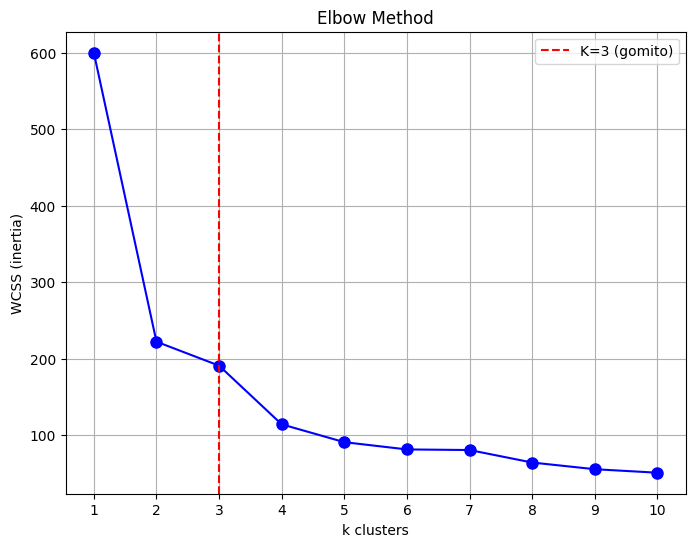

In [20]:
K_elbow = 3

plt.figure(figsize=(8, 6))
plt.plot(k_values, wcss, "o-", color="blue", markersize=8) 
plt.axvline(x=K_elbow, color="red", linestyle="--", label=f"K={K_elbow} (gomito)")
plt.xlabel("k clusters")
plt.ylabel("WCSS (inertia)")
plt.xticks(k_values)
plt.title("Elbow Method")
plt.grid(True)
plt.legend()
plt.show()

# 4. Applicazione finale & visualizzazione KMeans

In [24]:
from sklearn.metrics import silhouette_score

In [ ]:
# clusterizzazione definitiva con K_elbow=3
kmeans = KMeans(n_clusters=K_elbow, random_state=42)
labels = kmeans.fit_predict(X_std)

centroids = kmeans.cluster_centers_
n_iter = kmeans.n_iter_                # n° di iterazioni necessarie alla convergenza
score= silhouette_score(X_std, labels)

print(f"Silhouette score: {score:.2f}\nIterations: {n_iter}\nCentroids: \n{centroids}")

# 3 centroidi (uno per ogni cluster) con 4 valori (uno per ogni features)

Silhouette score: 0.48
Iterations: 4
Centroids: 
[[ 0.57100359 -0.37176778  0.69111943  0.66315198]
 [-0.81623084  1.31895771 -1.28683379 -1.2197118 ]
 [-1.32765367 -0.373138   -1.13723572 -1.11486192]]


In [31]:
# data reduction con PCA per riuscire a rappresentare in 2 dimensioni 
pca = PCA(n_components=2, random_state=42)  
X_pca = pca.fit_transform(X_std)

centroids_2d = pca.transform(centroids)    # come fatto per i punti, converto i centroidi in 2D

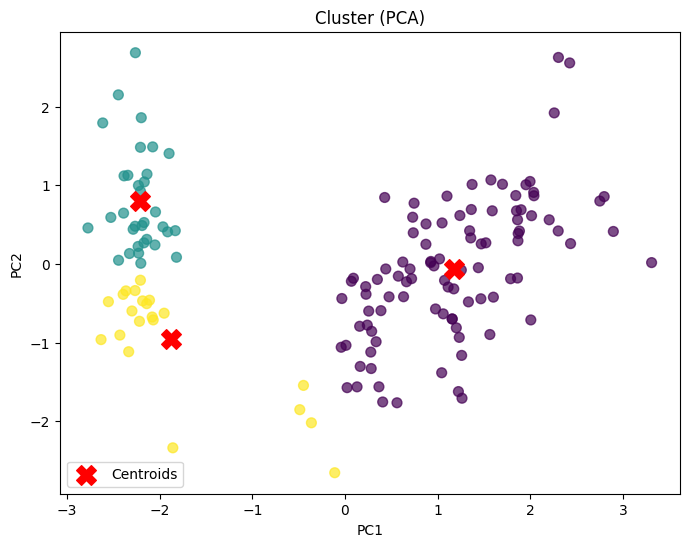

In [32]:
# grafico 2D PCA dei cluster con centroidi 
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="viridis", s=50, alpha=0.7)  
plt.scatter(
    centroids_2d[:, 0], centroids_2d[:, 1],   
    c="red",
    s=200,
    marker="X",
    label="Centroids"
)
plt.title("Cluster (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()